<a href="https://colab.research.google.com/github/nafilafiryal/data_mining/blob/main/6_Tugas2H.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving abalone.data.csv to abalone.data.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [5]:
kolom = ['Sex', 'Length', 'Diameter', 'Height',
         'Whole_weight', 'Shucked_weight',
         'Viscera_weight', 'Shell_weight', 'Rings']

df = pd.read_csv('abalone.data.csv', names=kolom)
df.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,Sex,Length,Diameter,Height,Whole weightShucked weight,Viscera weight,Shell weight,Rings,Age
1,M,0.455,0.365,0.095,0.514,0.2245,0.101,0.15,15
2,M,0.35,0.265,0.09,0.2255,0.0995,0.0485,0.07,7
3,F,0.53,0.42,0.135,0.677,0.2565,0.1415,0.21,9
4,M,0.44,0.365,0.125,0.516,0.2155,0.114,0.155,10


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4178 entries, 0 to 4177
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Sex             4178 non-null   object
 1   Length          4178 non-null   object
 2   Diameter        4178 non-null   object
 3   Height          4178 non-null   object
 4   Whole_weight    4178 non-null   object
 5   Shucked_weight  4178 non-null   object
 6   Viscera_weight  4178 non-null   object
 7   Shell_weight    4178 non-null   object
 8   Rings           4178 non-null   object
dtypes: object(9)
memory usage: 293.9+ KB


In [7]:
df.describe()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
count,4178,4178,4178,4178,4178,4178,4178,4178,4178
unique,4,135,112,52,2430,1516,881,927,29
top,M,0.55,0.45,0.15,0.2225,0.175,0.1715,0.275,9
freq,1528,94,139,267,8,11,15,43,689


In [8]:
# Cek missing values
df.isnull().sum()

,0
Sex,0
Length,0
Diameter,0
Height,0
Whole_weight,0
Shucked_weight,0
Viscera_weight,0
Shell_weight,0
Rings,0


In [12]:
# Load dataset
df = pd.read_csv('abalone.data.csv', encoding='utf-8-sig')

# Cek kolom yang terbaca
print("Kolom:", df.columns.tolist())
print("Jumlah kolom:", len(df.columns))
print(df.head())
print(df.dtypes)

Kolom: ['Sex', 'Length', 'Diameter', 'Height', 'Whole weightShucked weight', 'Viscera weight', 'Shell weight', 'Rings', 'Age']
Jumlah kolom: 9
  Sex  Length  Diameter  Height  Whole weightShucked weight  Viscera weight  \
0   M   0.455     0.365   0.095                      0.5140          0.2245   
1   M   0.350     0.265   0.090                      0.2255          0.0995   
2   F   0.530     0.420   0.135                      0.6770          0.2565   
3   M   0.440     0.365   0.125                      0.5160          0.2155   
4   I   0.330     0.255   0.080                      0.2050          0.0895   

   Shell weight  Rings  Age  
0        0.1010  0.150   15  
1        0.0485  0.070    7  
2        0.1415  0.210    9  
3        0.1140  0.155   10  
4        0.0395  0.055    7  
Sex                            object
Length                        float64
Diameter                      float64
Height                        float64
Whole weightShucked weight    float64
Viscera weig

In [13]:
# Pastikan kolom Age bertipe numerik
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# Cek nilai Age
print("Min Age:", df['Age'].min())
print("Max Age:", df['Age'].max())
print("Tipe data Age:", df['Age'].dtype)

Min Age: 1
Max Age: 29
Tipe data Age: int64


In [14]:
# Buat Age_Category dari kolom Age (bukan Rings)
df['Age_Category'] = df['Age'].apply(lambda x: 'old' if x > 10 else 'young')

# Cek distribusi kelas
print(df['Age_Category'].value_counts())

Age_Category
young    2730
old      1447
Name: count, dtype: int64


In [15]:
# Hapus kolom Age, Rings, dan Sex
df_model = df.drop(columns=['Age', 'Rings', 'Sex'])

# Pisahkan fitur dan label
X = df_model.drop(columns=['Age_Category'])
y = df_model['Age_Category']

print("Ukuran X:", X.shape)
print("Kolom fitur:", X.columns.tolist())

Ukuran X: (4177, 6)
Kolom fitur: ['Length', 'Diameter', 'Height', 'Whole weightShucked weight', 'Viscera weight', 'Shell weight']


In [16]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Mapping label:", dict(zip(le.classes_, le.transform(le.classes_))))

Mapping label: {'old': np.int64(0), 'young': np.int64(1)}


In [17]:
# Normalisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42
)

print("Data training:", X_train.shape)
print("Data testing :", X_test.shape)

Data training: (3341, 6)
Data testing : (836, 6)


In [18]:
# Bangun model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)

# Akurasi
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Accuracy: 0.7871 (78.71%)


In [19]:
print(classification_report(y_test, y_pred,
      target_names=le.classes_))

              precision    recall  f1-score   support

         old       0.70      0.62      0.66       276
       young       0.82      0.87      0.85       560

    accuracy                           0.79       836
   macro avg       0.76      0.74      0.75       836
weighted avg       0.78      0.79      0.78       836



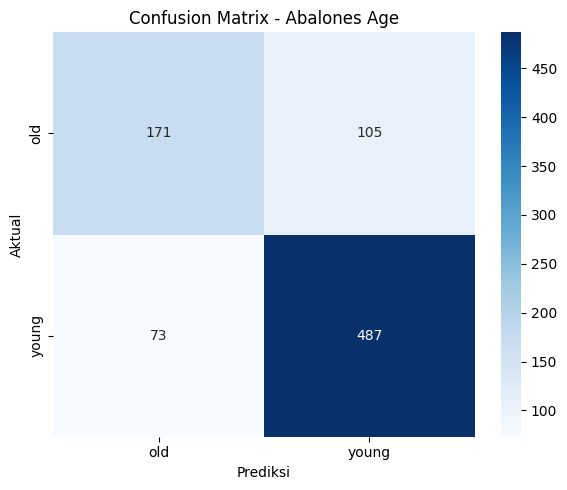

In [20]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix - Abalones Age")
plt.tight_layout()
plt.show()